# METAR GeoParquet Analysis and Visualization
---

## Overview
   
Within this notebook, we will cover:

1. Browser-based interactive maps of point-based data 
1. [Geopandas](https://geopandas.org/en/stable/)

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [Cartopy Intro](https://foundations.projectpythia.org/core/cartopy/cartopy.html) | Required | Projections and Features |
| [Pandas](https://foundations.projectpythia.org/core/pandas.html) | Required | Tabular Datasets |

- **Time to learn**: 20 minutes
---

## Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from cartopy import crs as ccrs
from cartopy import feature as cfeature
from datetime import datetime,timedelta
from dateutil.relativedelta import relativedelta

import geopandas as gpd
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import duckdb

In [2]:
con = duckdb.connect()

In [3]:
duckdb.install_extension("spatial", connection=con)
duckdb.load_extension("spatial", connection=con)

In [5]:
daily = pd.read_parquet('/spare11/atm350/ktyle/extras/daily/2025/20250531_metar.parquet')

In [6]:
base = "https://data.source.coop/dynamical/asos-parquet"
urls = [f"{base}/year={y}/data.parquet" for y in range(2025, datetime.now().year + 1)]

df = duckdb.execute("""
    SELECT valid, station, name, country, tmpf, dwpf, sknt, p01i,geometry
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = 'ALB'
    ORDER BY valid
""", [urls]).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
base = "https://data.source.coop/dynamical/asos-parquet"
urls = [f"{base}/year={y}/data.parquet" for y in range(2026, datetime.now().year + 1)]

df = duckdb.execute("""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE station = 'ALB'
    ORDER BY valid
""", [urls]).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
df

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,geometry,name,elevation,country,county,wfo,tzname,bbox,year
0,ALB,2026-01-01 00:51:00+00:00,-73.8036,42.7576,25.0,-3.89,17.0,-8.33,71.20,170.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
1,ALB,2026-01-01 01:51:00+00:00,-73.8036,42.7576,25.0,-3.89,15.0,-9.44,65.27,150.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
2,ALB,2026-01-01 02:51:00+00:00,-73.8036,42.7576,25.0,-3.89,17.0,-8.33,71.20,160.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
3,ALB,2026-01-01 03:51:00+00:00,-73.8036,42.7576,25.0,-3.89,18.0,-7.78,74.34,160.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
4,ALB,2026-01-01 04:51:00+00:00,-73.8036,42.7576,25.0,-3.89,19.0,-7.22,77.60,170.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,ALB,2026-02-12 00:04:00+00:00,-73.8036,42.7576,32.0,0.00,25.0,-3.89,75.05,300.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
1346,ALB,2026-02-12 00:13:00+00:00,-73.8036,42.7576,31.0,-0.56,26.0,-3.33,81.46,290.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
1347,ALB,2026-02-12 00:20:00+00:00,-73.8036,42.7576,31.0,-0.56,26.0,-3.33,81.46,290.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026
1348,ALB,2026-02-12 00:22:00+00:00,-73.8036,42.7576,31.0,-0.56,25.0,-3.89,78.15,290.0,...,NY,"[1, 1, 0, 0, 0, 51, 196, 177, 46, 110, 115, 82...",ALBANY COUNTY ARPT,89.0,US,Albany,ALY,America/New_York,"{'xmin': -73.8036, 'ymin': 42.7576, 'xmax': -7...",2026


In [10]:
df.columns

Index(['station', 'valid', 'longitude', 'latitude', 'tmpf', 'tmpc', 'dwpf',
       'dwpc', 'relh', 'drct', 'sknt', 'gust', 'alti', 'mslp', 'vsby', 'p01i',
       'p01m', 'state', 'geometry', 'name', 'elevation', 'country', 'county',
       'wfo', 'tzname', 'bbox', 'year'],
      dtype='object')

In [6]:
daily

,STN,YYMMDD/HHMM,LAT,LON,Elevation,PMSL,ALTI,TMPC,DWPC,SKNT,...,CTYH,P06I,T6XC,T6NC,CEIL,P01I,SNEW,HEAT,WCHT,geometry
Time,,,,,,,,,,,,,,,,,,,,,
2025-05-30 00:00:00+00:00,DYS,250530/0000,32.43,-99.85,545.0,1012.5,NaN,25.9,21.9,6.0,...,NaN,0.29,31.4,25.7,2.0,0.29,NaN,79.88,78.62,b'\x01\x01\x00\x00\x00fffff\xf6X\xc0\xd7\xa3p=...
2025-05-30 00:00:00+00:00,NUW,250530/0000,48.35,-122.65,14.0,1024.2,NaN,14.4,7.8,13.0,...,NaN,0.00,16.1,11.1,55.0,NaN,NaN,56.44,54.80,b'\x01\x01\x00\x00\x00\x9a\x99\x99\x99\x99\xa9...
2025-05-30 00:00:00+00:00,NYL,250530/0000,32.65,-114.62,65.0,1009.0,NaN,35.0,1.7,13.0,...,NaN,NaN,36.1,31.1,250.0,NaN,NaN,90.16,95.00,b'\x01\x01\x00\x00\x00H\xe1z\x14\xae\xa7\\\xc0...
2025-05-30 00:00:00+00:00,PALU,250530/0000,68.88,-166.13,3.0,998.3,NaN,-1.9,-4.4,3.0,...,NaN,NaN,-1.7,-2.8,15.0,NaN,NaN,28.58,24.81,b'\x01\x01\x00\x00\x00\\\x8f\xc2\xf5(\xc4d\xc0...
2025-05-30 00:00:00+00:00,PAIM,250530/0000,66.00,-153.70,389.0,992.5,NaN,3.3,0.3,5.0,...,NaN,0.01,3.5,0.5,18.0,NaN,NaN,37.94,33.48,b'\x01\x01\x00\x00\x00fffff6c\xc0\x00\x00\x00\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-31 23:00:00+00:00,MGCB,250531/2300,15.47,-90.41,1323.0,NaN,NaN,24.0,21.0,4.0,...,NaN,NaN,NaN,NaN,18.0,NaN,NaN,76.34,75.20,b'\x01\x01\x00\x00\x00\n\xd7\xa3p=\x9aV\xc0q=\...
2025-05-31 23:00:00+00:00,MGZA,250531/2300,14.96,-89.54,193.0,NaN,NaN,37.0,16.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.39,98.60,b'\x01\x01\x00\x00\x00\xc3\xf5(\\\x8fbV\xc0\xe...
2025-05-31 23:00:00+00:00,MGES,250531/2300,14.57,-89.33,949.0,NaN,NaN,31.0,18.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.33,87.80,b'\x01\x01\x00\x00\x00\x85\xebQ\xb8\x1eUV\xc0\...


In [ ]:
daily.columns

In [ ]:
year = 2025

In [ ]:
con.execute("DROP TABLE metar")

In [7]:
sql = """
CREATE TABLE metar AS
SELECT 
    Time, STN, TMPC, DWPC, PMSL, ALTI, P01I, LAT, LON, SKNT, DRCT, GUST, WNUM, CHC1, CHC2, CHC3, VSBY, P03D, P03I, SNOW, WEQS, P24I, TDXC, TDNC, P03C, CTYL, CTYM, CTYH, P06I, T6XC, T6NC, CEIL, HEAT, WCHT,
    ST_Point(LON, LAT) as geometry
FROM "yearly/2025_metar.parquet" 
WHERE
    Time BETWEEN '2025-01-01 00:00:00' AND '2025-05-31 23:59:00' AND
    STN = 'ALB' OR 
    STN = 'ROC'
LIMIT 10_000_000;
"""

In [ ]:
sql = """
CREATE TABLE metar AS
SELECT 
    Time, STN, TMPC, LON, LAT,
    ST_Point(LON, LAT) as geometry
FROM "yearly/2022-2024_metar.parquet" 
WHERE
    Time BETWEEN '2024-09-07 00:00:00' AND '2024-09-07 01:00:00' AND
    TMPC > 30
LIMIT 10_000_000;
"""

In [9]:
%time db = con.execute(sql)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: user 7.2 s, sys: 187 ms, total: 7.38 s
Wall time: 3.81 s


In [10]:
table = con.table("metar")

df = table.df()

In [11]:
gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.LON,df.LAT))

In [12]:
df

,Time,STN,TMPC,DWPC,PMSL,ALTI,P01I,LAT,LON,SKNT,...,CTYL,CTYM,CTYH,P06I,T6XC,T6NC,CEIL,HEAT,WCHT,geometry
0,2025-01-01 00:00:00+00:00,ALB,5.0,-0.6,1009.0,29.79,NaN,42.75,-73.80,0.0,...,NaN,NaN,NaN,NaN,10.6,5.0,180.0,37.95,41.00,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
1,2025-01-01 00:00:00+00:00,ROC,6.7,3.3,1002.3,29.58,0.04,43.12,-77.67,5.0,...,NaN,NaN,NaN,0.05,8.3,6.7,46.0,41.87,40.74,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,2025-01-01 01:00:00+00:00,ALB,5.0,0.0,1007.9,29.76,NaN,42.75,-73.80,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,150.0,38.09,41.00,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
3,2025-01-01 01:00:00+00:00,ROC,6.1,3.3,1001.9,29.57,0.02,43.12,-77.67,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,45.0,40.84,38.78,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
4,2025-01-01 02:00:00+00:00,ALB,5.0,-0.6,1006.1,29.71,NaN,42.75,-73.80,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,140.0,37.95,39.00,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7065,2025-05-31 21:00:00+00:00,ROC,11.7,4.4,999.4,29.50,NaN,43.12,-77.67,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,31.0,50.93,49.10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
7066,2025-05-31 22:00:00+00:00,ALB,10.0,7.8,992.7,29.32,0.01,42.75,-73.80,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,48.75,43.47,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
7067,2025-05-31 22:00:00+00:00,ROC,11.1,5.0,999.8,29.52,NaN,43.12,-77.67,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,41.0,49.98,46.71,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
7068,2025-05-31 23:00:00+00:00,ALB,9.4,7.8,993.6,29.34,0.03,42.75,-73.80,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,22.0,47.73,43.00,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


<Axes: >

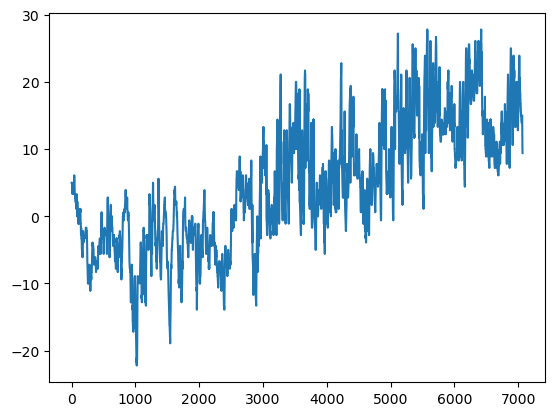

In [13]:
df[df.STN == 'ALB'].TMPC.plot()

In [ ]:
%%time
sql = """
CREATE TABLE metar AS
SELECT 
    Time, STN, TMPC, DWPC, PMSL, ALTI, P01I,
    ST_Point(LON, LAT) as geometry
FROM "s3://us-west-2.opendata.source.coop/ktyle/metar2024/2024_metar.parquet" 
WHERE
    Time BETWEEN '2024-01-01 00:00:00' AND '2024-12-31 23:59:00' AND
    STN = 'ALB'
LIMIT 10_000_000;
"""
db = con.execute(sql)
# 72 s to load from S3 Source Coop bucket

In [ ]:
%%time
sql = """
CREATE TABLE metar AS
SELECT 
    Time, STN, TMPC, DWPC, PMSL, ALTI, P01I, LON, LAT,
    ST_Point(LON, LAT) as geometry
FROM "s3://us-west-2.opendata.source.coop/ktyle/metar2024/2024_metar.parquet" 
WHERE
    Time BETWEEN '2024-05-01 00:00:00' AND '2024-05-01 01:00:00'
LIMIT 10_000_000;
"""
db = con.execute(sql)
# 72 s to load from S3 Source Coop bucket

In [ ]:
df

In [ ]:
df[df['TMPC'] < -10]

In [ ]:
df.PMSL.plot()

In [ ]:
8536/24

In [ ]:
con.execute("DROP TABLE metar")

In [ ]:
con.execute("DROP TABLE tmpc")

In [14]:
layer = ScatterplotLayer.from_duckdb(con.table("metar"), con, radius_min_pixels=2.5)

/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:33: UserWarning: No CRS exists on data. If no data is shown on the map, double check that your CRS is WGS84.
  warn(


In [15]:
m = Map(layer)

May run into a JavaScript error if running from JupyterHub, likely due to lack of `anywidget` package in the Jupyterhub environment. 

In [16]:
m

Map(custom_attribution='', layers=(ScatterplotLayer(radius_min_pixels=2.5, table=arro3.core.Table
-----------
…

In [ ]:
db.close()

In [ ]:
duckdb.query('''
   SELECT *
   FROM 'db'
   WHERE TMPC BETWEEN '22.0' AND '24.0' AND Time BETWEEN '2024-06-23 00:00:00' AND '2024-06-23 02:00:00'
''')

In [ ]:
duckdb.query('''
   SELECT *
   FROM '20240623_metar.parquet'
   WHERE TMPC BETWEEN '22.0' AND '24.0' AND Time BETWEEN '2024-06-23 00:00:00' AND '2024-06-23 02:00:00'
''')

In [ ]:
db.

In [ ]:
viz(sample.loc['2024-06-23T23:00'])

In [ ]:
gdf.explore('TMPC')

In [ ]:
gdfWorldMetar.explore(column='TMPC')

<div class="alert alert-info"><b>Note: </b> Most of the non-US data is not available until approximately 15 minutes past each hour. If you do not see many worldwide stations, try re-reading the data file after that point in the hour.</div>

<div class="alert alert-warning"><b>Exercise: </b> Create a color-coded map from one variable in the dataset.</div>

In [ ]:
# Write your code here
gdfWorldMetar.explore(column='TMPC')

<div class="alert alert-info">Note that the color scale is unaffected by any location whose temperature value was missing ... GeoPandas "knows" to exlucde <code>NaN</code> from the range of valid values.</div>

Plot hourly precipitation

In [ ]:
gdfWorldMetar.explore(column='P01M')

<div class="alert alert-info">With few exceptions, hourly precip is only provided by US stations. For this variable, a better visualization would exclude all the missing values (in the US, a missing value denotes <b>no precip</b>, while a <b>trace</b> = 0.00)</div>

In [ ]:
gdfWorldMetar = gdfWorldMetar.dropna(subset=['P01M']).reset_index(drop=True)

In [ ]:
gdfWorldMetar.explore(column='P01M')

## References

1. [GeoPandas](https://geopandas.org)
1. [EPSG](https://epsg.io)